<a href="https://colab.research.google.com/github/ercenttannius123/Liver-Tumor-Detection/blob/main/Liver%20Tumor%20Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ercenttannius","key":"b46cd255000b60c9ed0d1e09034c2893"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API siap!")

✅ Kaggle API siap!


In [ ]:
!kaggle datasets download -d andrewmvd/liver-tumor-segmentation
print("✅ Download selesai!")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/liver-tumor-segmentation
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 4.84G/4.84G [00:56<00:00, 91.9MB/s]

✅ Download selesai!


In [ ]:
!unzip liver-tumor-segmentation.zip -d /content/dataset
print("✅ Extract selesai!")

Archive:  liver-tumor-segmentation.zip
  inflating: /content/dataset/segmentations/segmentation-0.nii  
  inflating: /content/dataset/segmentations/segmentation-1.nii  
  inflating: /content/dataset/segmentations/segmentation-10.nii  
  inflating: /content/dataset/segmentations/segmentation-100.nii  
  inflating: /content/dataset/segmentations/segmentation-101.nii  
  inflating: /content/dataset/segmentations/segmentation-102.nii  
  inflating: /content/dataset/segmentations/segmentation-103.nii  
  inflating: /content/dataset/segmentations/segmentation-104.nii  
  inflating: /content/dataset/segmentations/segmentation-105.nii  
  inflating: /content/dataset/segmentations/segmentation-106.nii  
  inflating: /content/dataset/segmentations/segmentation-107.nii  
  inflating: /content/dataset/segmentations/segmentation-108.nii  
  inflating: /content/dataset/segmentations/segmentation-109.nii  
  inflating: /content/dataset/segmentations/segmentation-11.nii  
  inflating: /content/dataset

In [ ]:
import os

dataset_path = '/content/dataset'
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:3]:
            print(f"{indent}  {f}")

dataset/
  volume_pt3/
    volume-26.nii
    volume-25.nii
    volume-24.nii
  volume_pt5/
    volume-50.nii
    volume-45.nii
    volume-41.nii
  volume_pt4/
    volume-40.nii
    volume-34.nii
    volume-33.nii
  segmentations/
    segmentation-81.nii
    segmentation-110.nii
    segmentation-76.nii
  volume_pt1/
    volume-3.nii
    volume-4.nii
    volume-5.nii
  volume_pt2/
    volume-14.nii
    volume-19.nii
    volume-16.nii


In [ ]:
!pip install nibabel -q

import os, cv2, nibabel as nib, numpy as np, torch
import torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt

DATASET_PATH  = "/content/dataset"
VOLUME_DIRS   = [f"{DATASET_PATH}/volume_pt{i}" for i in range(1, 6)]
SEGMEN_DIR    = f"{DATASET_PATH}/segmentations"
OUT_IMG       = "/content/slices/images"
OUT_MASK      = "/content/slices/masks"

IMG_SIZE      = 128
BATCH_SIZE    = 16
EPOCHS        = 30
LEARNING_RATE = 1e-4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {DEVICE}")

✅ Device: cuda


In [ ]:
def convert_all_volumes(volume_dirs, segmen_dir, out_img, out_mask):
    os.makedirs(out_img,  exist_ok=True)
    os.makedirs(out_mask, exist_ok=True)
    saved, skipped = 0, 0

    all_vol_files = []
    for vdir in volume_dirs:
        for f in os.listdir(vdir):
            if f.endswith(".nii"):
                all_vol_files.append(os.path.join(vdir, f))

    print(f"Total volume: {len(all_vol_files)}")

    for vol_path in tqdm(all_vol_files, desc="Konversi NIfTI"):
        fname    = os.path.basename(vol_path)
        num      = fname.replace("volume-", "").replace(".nii", "")
        seg_path = os.path.join(segmen_dir, f"segmentation-{num}.nii")

        if not os.path.exists(seg_path):
            skipped += 1
            continue

        vol_data = nib.load(vol_path).get_fdata()
        seg_data = nib.load(seg_path).get_fdata()

        for i in range(vol_data.shape[2]):
            mask_slice = seg_data[:, :, i]
            if mask_slice.max() == 0:
                continue
            img_slice = vol_data[:, :, i]
            img_clip  = np.clip(img_slice, -150, 250)
            img_norm  = ((img_clip - img_clip.min()) /
                        (img_clip.max() - img_clip.min() + 1e-8) * 255).astype(np.uint8)
            mask_bin  = (mask_slice > 0).astype(np.uint8) * 255
            img_res   = cv2.resize(img_norm,  (IMG_SIZE, IMG_SIZE))
            mask_res  = cv2.resize(mask_bin, (IMG_SIZE, IMG_SIZE),
                                   interpolation=cv2.INTER_NEAREST)
            filename  = f"vol{num}_slice{i:04d}.png"
            cv2.imwrite(os.path.join(out_img,  filename), img_res)
            cv2.imwrite(os.path.join(out_mask, filename), mask_res)
            saved += 1

    print(f"✅ Slice tersimpan: {saved} | Di-skip: {skipped}")

convert_all_volumes(VOLUME_DIRS, SEGMEN_DIR, OUT_IMG, OUT_MASK)

Total volume: 51


Konversi NIfTI: 100%|██████████| 51/51 [01:52<00:00,  2.20s/it]

✅ Slice tersimpan: 6802 | Di-skip: 0


In [ ]:
from torch.utils.data import Dataset, DataLoader
import random
import numpy as np

class LiverDataset(Dataset):
    def __init__(self, img_paths, mask_paths):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img  = cv2.imread(self.img_paths[idx],  cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        img  = img.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0
        mask = (mask > 0.5).astype(np.float32)
        img  = torch.tensor(img).unsqueeze(0)
        mask = torch.tensor(mask).unsqueeze(0)
        return img, mask

# Load semua path
all_imgs  = sorted([os.path.join(OUT_IMG,  f) for f in os.listdir(OUT_IMG)])
all_masks = sorted([os.path.join(OUT_MASK, f) for f in os.listdir(OUT_MASK)])

# Hitung foreground ratio tiap slice
print("Menghitung foreground ratio tiap slice...")
fg_ratios = []
for mask_path in all_masks:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    ratio = (mask > 127).sum() / mask.size
    fg_ratios.append(ratio)
fg_ratios = np.array(fg_ratios)

# Bagi ke 3 strata
strata = np.zeros(len(fg_ratios), dtype=int)
strata[fg_ratios >= 0.05] = 1
strata[fg_ratios >= 0.15] = 2

print(f"Strata 0 (sedikit, fg<5%)  : {(strata==0).sum()} slice")
print(f"Strata 1 (sedang, 5-15%)   : {(strata==1).sum()} slice")
print(f"Strata 2 (banyak, fg>=15%) : {(strata==2).sum()} slice")

# Stratified split 80/20
random.seed(42)
X_train, y_train, X_val, y_val = [], [], [], []

for s in range(3):
    idx_s = np.where(strata == s)[0].tolist()
    random.shuffle(idx_s)
    split = int(len(idx_s) * 0.8)
    train_idx = idx_s[:split]
    val_idx   = idx_s[split:]
    X_train += [all_imgs[i]  for i in train_idx]
    y_train += [all_masks[i] for i in train_idx]
    X_val   += [all_imgs[i]  for i in val_idx]
    y_val   += [all_masks[i] for i in val_idx]

print(f"\nStratified Split selesai!")
print(f"   Train : {len(X_train)} slice")
print(f"   Val   : {len(X_val)} slice")

# Buat DataLoader
train_ds     = LiverDataset(X_train, y_train)
val_ds       = LiverDataset(X_val,   y_val)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"   Train DataLoader: {len(train_loader)} batch")
print(f"   Val DataLoader  : {len(val_loader)} batch")

Menghitung foreground ratio tiap slice...
Strata 0 (sedikit, fg<5%)  : 2946 slice
Strata 1 (sedang, 5-15%)   : 3498 slice
Strata 2 (banyak, fg>=15%) : 358 slice

Stratified Split selesai!
   Train : 5440 slice
   Val   : 1362 slice
   Train DataLoader: 340 batch
   Val DataLoader  : 86 batch


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ConvBlock(1, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)
        self.enc4 = ConvBlock(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(512, 1024)

        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = ConvBlock(1024, 512)

        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlock(512, 256)

        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(256, 128)

        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ConvBlock(128, 64)

        self.out  = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b  = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return torch.sigmoid(self.out(d1))


# ---- Plain CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, 1)
        )

    def forward(self, x):
        return torch.sigmoid(self.net(x))


# ---- SegNet (simple)
class SimpleSegNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 1, 3, padding=1)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return torch.sigmoid(x)


In [ ]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred_f   = pred.view(-1)
        target_f = target.view(-1)

        intersection = (pred_f * target_f).sum()

        dice_loss = 1 - (2. * intersection + self.smooth) / \
                        (pred_f.sum() + target_f.sum() + self.smooth)

        bce_loss = nn.BCELoss()(pred, target)

        return dice_loss + bce_loss


def compute_metrics(pred, target, threshold=0.5):
    pred_bin  = (pred > threshold).float()

    pred_np   = pred_bin.cpu().numpy().flatten().astype(int)
    target_np = target.cpu().numpy().flatten().astype(int)

    tn, fp, fn, tp = confusion_matrix(target_np, pred_np, labels=[0,1]).ravel()

    return dict(
        accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-8),
        precision   = tp / (tp + fp + 1e-8),
        recall      = tp / (tp + fn + 1e-8),
        specificity = tn / (tn + fp + 1e-8),
        dice        = (2 * tp) / (2 * tp + fp + fn + 1e-8),
        jaccard     = tp / (tp + fp + fn + 1e-8),
    )

models = {
    "CNN": SimpleCNN().to(DEVICE),
    "SegNet": SimpleSegNet().to(DEVICE),
    "UNet": UNet().to(DEVICE)
}

print("✅ Semua model siap!")


✅ Semua model siap!


In [ ]:
results = {}

for name, model in models.items():

    print(f"\n🚀 Training {name}")

    loss_fn   = DiceBCELoss().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5
    )

    best_dice = 0.0

    for epoch in range(EPOCHS):

        # ===== TRAIN =====
        model.train()
        train_loss = 0.0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            optimizer.zero_grad()
            preds = model(imgs)

            loss = loss_fn(preds, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0.0
        all_preds, all_targets = [], []

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

                preds = model(imgs)
                val_loss += loss_fn(preds, masks).item()

                all_preds.append(preds)
                all_targets.append(masks)

        val_loss /= len(val_loader)

        all_preds   = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)

        metrics = compute_metrics(all_preds, all_targets)

        scheduler.step(val_loss)

        print(f"{name} | Epoch {epoch+1}/{EPOCHS} | Dice: {metrics['dice']:.4f}")

        # ===== SAVE BEST =====
        if metrics["dice"] > best_dice:
            best_dice = metrics["dice"]
            torch.save(model.state_dict(), f"/content/best_{name}.pth")

    print(f"✅ {name} selesai! Best Dice: {best_dice:.4f}")
    results[name] = best_dice


# =========================================
# FINAL RESULT
# =========================================

print("\n=== FINAL RESULT ===")
for k, v in results.items():
    print(f"{k}: Best Dice = {v:.4f}")`




🚀 Training CNN
CNN | Epoch 1/30 | Dice: 0.6133
CNN | Epoch 2/30 | Dice: 0.6502
CNN | Epoch 3/30 | Dice: 0.6638
CNN | Epoch 4/30 | Dice: 0.6717
CNN | Epoch 5/30 | Dice: 0.6904
CNN | Epoch 6/30 | Dice: 0.6965
CNN | Epoch 7/30 | Dice: 0.7035
CNN | Epoch 8/30 | Dice: 0.7031
CNN | Epoch 9/30 | Dice: 0.7050
CNN | Epoch 10/30 | Dice: 0.7060
CNN | Epoch 11/30 | Dice: 0.7078
CNN | Epoch 12/30 | Dice: 0.7036
CNN | Epoch 13/30 | Dice: 0.7085
CNN | Epoch 14/30 | Dice: 0.7093
CNN | Epoch 15/30 | Dice: 0.7111
CNN | Epoch 16/30 | Dice: 0.7111
CNN | Epoch 17/30 | Dice: 0.7116
CNN | Epoch 18/30 | Dice: 0.7117
CNN | Epoch 19/30 | Dice: 0.7115
CNN | Epoch 20/30 | Dice: 0.7127
CNN | Epoch 21/30 | Dice: 0.7127
CNN | Epoch 22/30 | Dice: 0.7116
CNN | Epoch 23/30 | Dice: 0.7130
CNN | Epoch 24/30 | Dice: 0.7128
CNN | Epoch 25/30 | Dice: 0.7135
CNN | Epoch 26/30 | Dice: 0.7134
CNN | Epoch 27/30 | Dice: 0.7127
CNN | Epoch 28/30 | Dice: 0.7138
CNN | Epoch 29/30 | Dice: 0.7139
CNN | Epoch 30/30 | Dice: 0.7141
✅ C

In [ ]:
final_metrics = {}

for name, model in models.items():

    print(f"\n🔍 Evaluating {name}")

    # load model terbaik
    model.load_state_dict(torch.load(f"/content/best_{name}.pth"))
    model.eval()

    all_preds, all_targets = [], []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            preds = model(imgs)

            all_preds.append(preds)
            all_targets.append(masks)

    all_preds   = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    metrics = compute_metrics(all_preds, all_targets)

    final_metrics[name] = metrics

    print(f"{name} Metrics:")
    for k, v in metrics.items():
        print(f"   {k}: {v:.4f}")


🔍 Evaluating CNN
CNN Metrics:
   accuracy: 0.9601
   precision: 0.6771
   recall: 0.7554
   specificity: 0.9745
   dice: 0.7141
   jaccard: 0.5554

🔍 Evaluating SegNet
SegNet Metrics:
   accuracy: 0.9599
   precision: 0.6668
   recall: 0.7839
   specificity: 0.9723
   dice: 0.7206
   jaccard: 0.5632

🔍 Evaluating UNet
UNet Metrics:
   accuracy: 0.9982
   precision: 0.9847
   recall: 0.9874
   specificity: 0.9989
   dice: 0.9860
   jaccard: 0.9725


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Dice Score": list(results.values())
})

print(results_df)

results_df.to_csv("/content/model_results.csv", index=False)
print("✅ Tabel hasil disimpan!")

    Model  Dice Score
0     CNN    0.714132
1  SegNet    0.720601
2    UNet    0.986047
✅ Tabel hasil disimpan!


In [ ]:
df = pd.DataFrame(final_metrics).T

df.reset_index(inplace=True)
df.rename(columns={"index": "Model"}, inplace=True)

print("\n=== FULL METRICS RESULT ===")
print(df)

df.to_csv("/content/full_metrics.csv", index=False)
print("✅ Full metrics disimpan!")


=== FULL METRICS RESULT ===
    Model  accuracy  precision    recall  specificity      dice   jaccard
0     CNN  0.960069   0.677099  0.755450     0.974533  0.714132  0.555369
1  SegNet  0.959866   0.666755  0.783907     0.972304  0.720601  0.563234
2    UNet  0.998155   0.984693  0.987404     0.998915  0.986047  0.972478
✅ Full metrics disimpan!


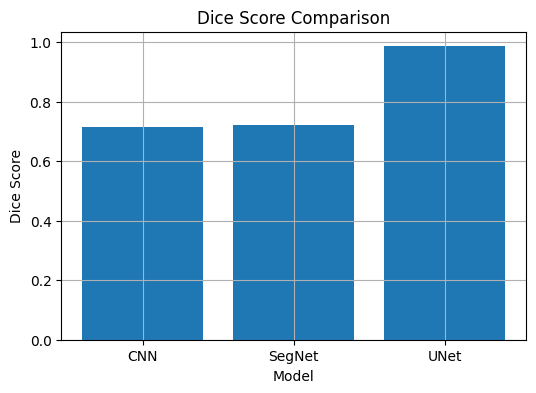

In [ ]:
import matplotlib.pyplot as plt

models_name = df["Model"]
dice_scores = df["dice"]

plt.figure(figsize=(6,4))
plt.bar(models_name, dice_scores)

plt.title("Dice Score Comparison")
plt.xlabel("Model")
plt.ylabel("Dice Score")
plt.grid(True)

plt.savefig("/content/dice_comparison.png", dpi=150)
plt.show()

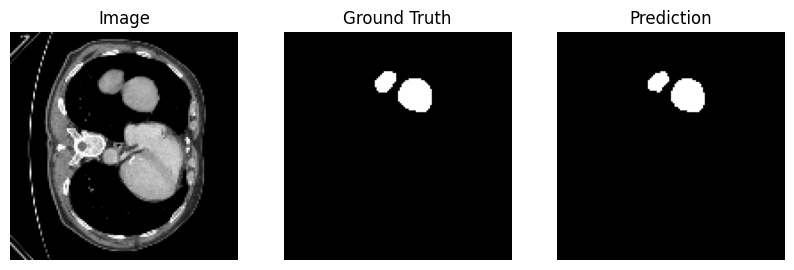

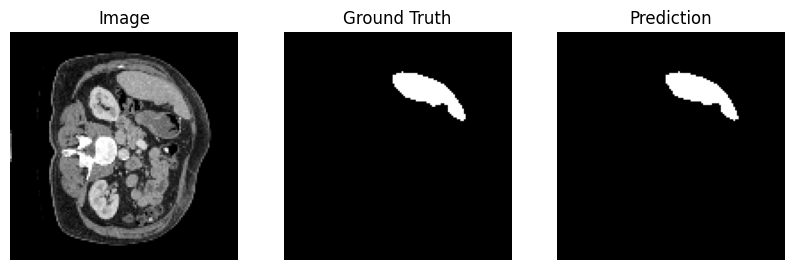

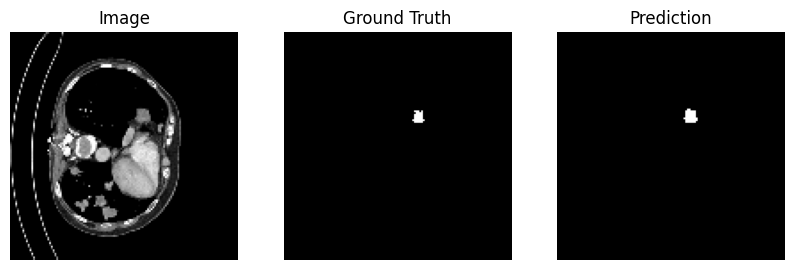

In [ ]:
import matplotlib.pyplot as plt

# ambil model terbaik (UNet)
model = models["UNet"]
model.load_state_dict(torch.load("/content/best_UNet.pth"))
model.eval()

# ambil 1 batch dari validation
imgs, masks = next(iter(val_loader))
imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

with torch.no_grad():
    preds = model(imgs)

# tampilkan 3 sample
for i in range(3):
    plt.figure(figsize=(10,3))

    # ORIGINAL IMAGE
    plt.subplot(1,3,1)
    plt.imshow(imgs[i].cpu().squeeze(), cmap='gray')
    plt.title("Image")
    plt.axis("off")

    # GROUND TRUTH
    plt.subplot(1,3,2)
    plt.imshow(masks[i].cpu().squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    # PREDICTION
    plt.subplot(1,3,3)
    plt.imshow((preds[i].cpu().squeeze() > 0.5), cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

    plt.show()